# Hello World - Coupled Magnetoelastic Theory
## Magnetoelastic Hysteresis

This notebook demonstrates the code used to reproduce the results in: Sablik, M.J.; Jiles, D.C., "Coupled magnetoelastic theory of magnetic and magnetostrictive hysteresis," in Magnetics, IEEE Transactions on , vol.29, no.4, pp.2113-2123, Jul 1993. 

Approximate reproduction of stress-dependent magnetization hysteresis curves
similar to the figure shown in the 1993 IEEE Transactions on Magnetics paper.

This is a practical, tunable implementation based on:
    1. Jiles–Atherton-like magnetization hysteresis
    2. Stress added through an effective field term
    3. Magnetostriction computed from magnetization


B. Howard

## Libraries

In [20]:
#import sys
#!{sys.executable} -m pip install subprocess

In [21]:
import sys
import os

# Add parent directory to path to import magnetoelasticsensor package
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

### Do the libraries we need exist?

In [22]:
import subprocess
import sys
import math

# Install required packages
required_packages = [
    'numpy',
    'pandas',
    'matplotlib',
]

print("Checking and installing required libraries...")
print("=" * 70)

for package in required_packages:
    try:
        __import__(package)
        print(f"✓ {package:12} is already installed")
    except ImportError:
        print(f"  Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f"✓ {package:12} installed successfully")

print("=" * 70)
print("✓ All required libraries are available!\n")

Checking and installing required libraries...
✓ numpy        is already installed
✓ pandas       is already installed
✓ matplotlib   is already installed
✓ All required libraries are available!



### Bring in the libraries

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from magnetoelasticsensor.anhyst_iso import anhysteretic_magnetization

### Constants

In [24]:
MU0 = 4.0e-7 * np.pi  # H/m

### Functions

## 1. Plot the results

Computed M_an at H = 300 A/m: 144738.354822 A/m
Expected M_an from test:           144738.354822 A/m
Absolute error:                    0.000000e+00 A/m


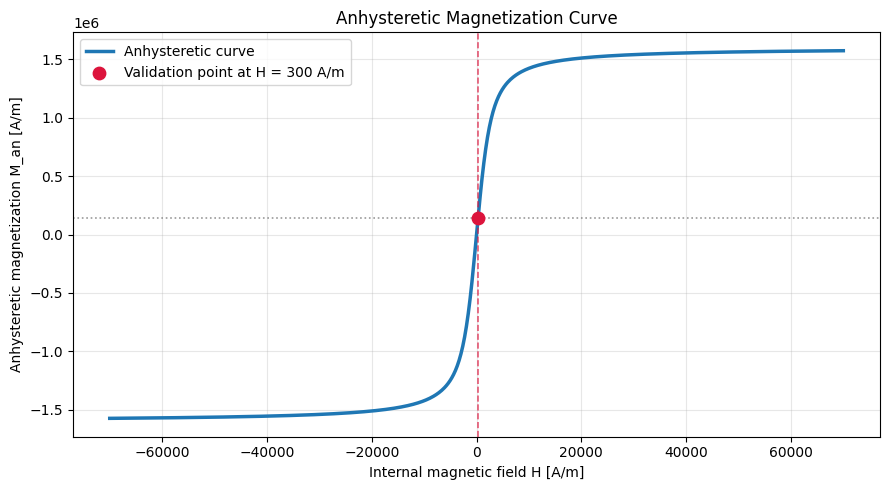

In [25]:
# Parameters from test_validate_figure03_ref02
ms = 1.6e6
m = 0.0
a = 1100
alpha = 0.0016

# Sweep the internal magnetic field to trace the anhysteretic curve
h_values = np.linspace(-70000, 70000, 801)
man_values = anhysteretic_magnetization(
    h=h_values,
    m=m,
    ms=ms,
    a=a,
    alpha=alpha,
 )

# Validation point from the unit test
h_test = 300.0
man_expected = 144738.3548215022
man_test = anhysteretic_magnetization(
    h=h_test,
    m=m,
    ms=ms,
    a=a,
    alpha=alpha,
 )

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h_values, man_values, linewidth=2.5, label='Anhysteretic curve')
ax.scatter(
    [h_test],
    [man_test],
    color='crimson',
    s=80,
    zorder=3,
    label='Validation point at H = 300 A/m',
)
ax.axvline(h_test, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axhline(man_expected, color='gray', linestyle=':', linewidth=1.2, alpha=0.8)

ax.set_title('Anhysteretic Magnetization Curve')
ax.set_xlabel('Internal magnetic field H [A/m]')
ax.set_ylabel('Anhysteretic magnetization M_an [A/m]')
ax.grid(True, alpha=0.3)
ax.legend()

print(f'Computed M_an at H = {h_test:.0f} A/m: {man_test:.6f} A/m')
print(f'Expected M_an from test:           {man_expected:.6f} A/m')
print(f'Absolute error:                    {abs(man_test - man_expected):.6e} A/m')

plt.tight_layout()
plt.show()